# Exploración de datos PAES 2026 — MATE2_MAX

Continuación de `01_exploracion_datos.ipynb`, `02_exploracion_clec_max.ipynb` y `03_exploracion_mate1_max.ipynb`. Se aplica el mismo procedimiento descriptivo a `MATE2_MAX`.

> **Nota al margen importante:** a diferencia de `CLEC_MAX` y `MATE1_MAX` (pruebas obligatorias), la Prueba de Matemática 2 es de **caracter optativo** dentro del proceso de admision — solo la exigen ciertas carreras. Esto cambia la interpretacion de los resultados de este notebook: aqui la proporcion de ceros no es un dato curioso al margen, sino el hallazgo central.

## Entorno y carga de datos

In [1]:
# Mismas rutas y misma fuente de datos que en los notebooks anteriores de esta serie
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DIRECTORIO_ACTUAL = Path.cwd()
DIRECTORIO_RAIZ = DIRECTORIO_ACTUAL.parent
RAW_DIR = DIRECTORIO_RAIZ / "data" / "raw"

In [2]:
# Carga del conjunto Inscritos y Puntajes (separador ';' y decimal ',')
RUTA_INSCRITOS = RAW_DIR / "PAES-2026-Inscritos-Puntajes" / "A_INSCRITOS_PUNTAJES_PAES_2026_PUB_MRUN.csv"

inscritos = pd.read_csv(RUTA_INSCRITOS, sep=";", decimal=",", low_memory=False)
inscritos.shape

(320087, 131)

## Foco de esta entrega: `MATE2_MAX`

Según la ficha de metadatos, `MATE2_MAX` corresponde al puntaje máximo obtenido entre todas las Pruebas de Matemática 2 rendidas.

In [3]:
# Verificamos el tipo de dato, mismo primer paso que en las variables anteriores
MATE2_MAX_col = inscritos["MATE2_MAX"]
MATE2_MAX_col.dtype

dtype('int64')

> **Nota al margen:** al igual que `CLEC_MAX` y `MATE1_MAX`, viene como `int64` — sin nulos por diseño de tipo. Se confirma a continuacion.

## Nulos vs. ceros

In [4]:
# Mismo criterio de las dos entregas anteriores: se distingue "no hay dato" (NaN) de "el dato es cero"
n_total = len(inscritos)
n_nulos = MATE2_MAX_col.isna().sum()
n_ceros = (MATE2_MAX_col == 0).sum()
n_validos = (MATE2_MAX_col > 0).sum()

resumen_mate2_max = pd.DataFrame({
    "Cantidad": [n_nulos, n_ceros, n_validos],
    "% del total": [
        round(n_nulos / n_total * 100, 2),
        round(n_ceros / n_total * 100, 2),
        round(n_validos / n_total * 100, 2),
    ]
}, index=["Nulos (NaN)", "En cero", "Puntaje > 0"])

resumen_mate2_max

,Cantidad,% del total
Nulos (NaN),0,0.00
En cero,193784,60.54
Puntaje > 0,126303,39.46


`MATE2_MAX` **no tiene valores nulos** (0,00%), pero **60,54% de las observaciones (193.784 casos)** registra un valor de cero — mas de la mitad del total. Esta proporcion es drasticamente mayor a la de `CLEC_MAX` (13,47%) y `MATE1_MAX` (14,63%), lo que amerita revisar si el criterio de interpretacion aplicado a esas dos variables (posible no-rendicion puntual) sigue siendo razonable aqui, o si responde a otra causa estructural.

### Contraste con `MATE2_REG_ACTUAL`: ¿es lo mismo que en CLEC_MAX y MATE1_MAX?

Se repite el cruce contra la variable de registro actual, igual que en `03_exploracion_mate1_max.ipynb`, para comparar si `MATE2_MAX` "rescata" una proporcion similar de casos.

In [5]:
# Conversion de MATE2_REG_ACTUAL a numerico (str -> numerico, mismo criterio que en notebooks anteriores)
reg_num = pd.to_numeric(inscritos["MATE2_REG_ACTUAL"], errors="coerce")

nulos_reg = reg_num.isna().sum()
ceros_reg = (reg_num == 0).sum()

# Casos "rescatados": sin dato en el proceso regular actual, pero con puntaje > 0 en MATE2_MAX
rescatados = ((reg_num.isna()) & (MATE2_MAX_col > 0)).sum()

print("Nulos en MATE2_REG_ACTUAL:", nulos_reg, f"({nulos_reg/n_total*100:.2f}%)")
print("Ceros en MATE2_REG_ACTUAL:", ceros_reg, f"({ceros_reg/n_total*100:.2f}%)")
print("Ceros en MATE2_MAX:       ", n_ceros, f"({n_ceros/n_total*100:.2f}%)")
print("Rescatados por MATE2_MAX: ", rescatados, f"({rescatados/n_total*100:.2f}%)")

Nulos en MATE2_REG_ACTUAL: 19496 (6.09%)
Ceros en MATE2_REG_ACTUAL: 193306 (60.39%)
Ceros en MATE2_MAX:        193784 (60.54%)
Rescatados por MATE2_MAX:  8533 (2.67%)

**Esto es lo que confirma la hipotesis del caracter optativo.** A diferencia de `CLEC_MAX` (rescata 5,72%) y `MATE1_MAX` (rescata 5,69%), `MATE2_MAX` solo rescata un **2,67%** de casos adicionales, y la tasa de ceros en `MATE2_REG_ACTUAL` (60,39%) es practicamente identica a la de `MATE2_MAX` (60,54%).

En otras palabras: los estudiantes que no registran `MATE2` en el proceso actual, mayoritariamente **tampoco la han rendido nunca** en ningun otro proceso. Esto es consistente con una prueba optativa que gran parte de los postulantes simplemente no necesita rendir (no aplica a la carrera a la que postulan), y no con una prueba obligatoria con problemas puntuales de registro.

**Implicancia para el analisis final:** tratar los 193.784 ceros de `MATE2_MAX` como "puntaje bajo" en un promedio o modelo va a introducir un sesgo severo (un falso "piso" en la distribucion). La alternativa mas defendible es modelar `MATE2_MAX` en dos partes: (1) una variable binaria "rindio Matematica 2" y (2) el puntaje condicional solo entre quienes si la rindieron. Esta decision de diseño se deja planteada para el equipo, no resuelta en este notebook.

## Estadisticos descriptivos

In [6]:
# Igual que en las variables anteriores. Aqui la mediana = 0 es esperable dado que mas del 60% de los casos son cero
print("Media:   ", MATE2_MAX_col.mean().round(1))
print("Mediana: ", MATE2_MAX_col.median().round(1))
print("Moda:    ", MATE2_MAX_col.mode().iloc[0], f"(n={n_ceros})")
print("Desv.Est:", MATE2_MAX_col.std().round(1))

Media:    168.4
Mediana:  0.0
Moda:     0 (n=193784)
Desv.Est: 216.3

> **Nota al margen:** que la *mediana* (no solo la moda) sea 0 es un indicador fuerte por si solo — significa que mas de la mitad de los 320.087 postulantes tiene un valor de cero en esta variable. Cuando la mediana coincide con el limite inferior de la escala, es una señal de que el promedio (168,4) no es representativo del "postulante tipico" y no deberia usarse sin mas contexto.

In [7]:
MATE2_MAX_col.describe().round(1)

count    320087.0
mean        168.4
std         216.3
min           0.0
25%           0.0
50%           0.0
75%         392.0
max        1000.0
Name: MATE2_MAX, dtype: float64

> **Nota al margen:** el propio `describe()` lo delata — el percentil 25 y la mediana (percentil 50) son ambos 0. Es decir, al menos la mitad de la distribucion esta "pegada" al piso de la escala.

## Distribucion por bandas de puntaje

In [8]:
# Mismas bandas de 100 en 100 puntos usadas en CLEC_MAX y MATE1_MAX, para mantener comparabilidad
tabla_bandas = inscritos["MATE2_MAX"].value_counts(bins=range(0, 1100, 100), sort=False).reset_index()
tabla_bandas.columns = ["Banda de puntaje", "Observaciones"]
tabla_bandas["Porcentaje"] = (tabla_bandas["Observaciones"] / n_total * 100).round(2)
tabla_bandas

Banda de puntaje,Observaciones,Porcentaje
"(-0.001, 100.0]",193835,60.56
"(100.0, 200.0]",54,0.02
"(200.0, 300.0]",3347,1.05
"(300.0, 400.0]",55105,17.22
"(400.0, 500.0]",48876,15.27
"(500.0, 600.0]",11836,3.70
"(600.0, 700.0]",4842,1.51
"(700.0, 800.0]",1673,0.52
"(800.0, 900.0]",466,0.15
"(900.0, 1000.0]",53,0.02


> **Nota al margen:** notese la forma inusual de la distribucion: despues del bloque masivo en 0-100, la segunda banda mas grande es 300-400 (17,22%), no 400-500 como en las otras dos variables. Entre quienes SI rinden Matematica 2, el patron de puntajes parece distinto al de Competencia Lectora y Matematica 1 — otra pista de que se trata de una subpoblacion distinta (probablemente con perfil mas orientado a carreras cientificas), no solo una version "con mas ceros" de las mismas pruebas.

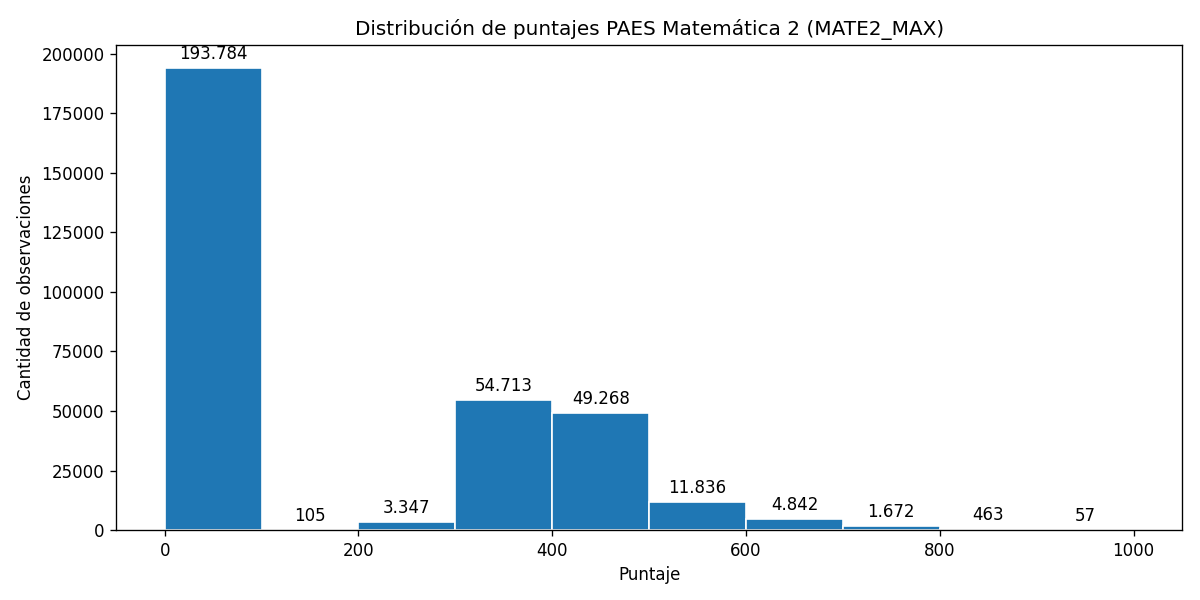

In [9]:
# Histograma con bandas de 100 puntos, mismo formato que CLEC_MAX y MATE1_MAX para comparabilidad visual
plt.figure(figsize=(10, 5))
conteos, bordes, barras = plt.hist(
    inscritos["MATE2_MAX"],
    bins=range(0, 1100, 100),
    color="#1f77b4",
    edgecolor="white"
)
plt.xlabel("Puntaje Matemática 2")
plt.ylabel("Cantidad de observaciones")
plt.title("Distribución de puntajes PAES Matemática 2 (MATE2_MAX)")
plt.bar_label(
    barras,
    labels=[f"{int(x):,}".replace(",", ".") for x in conteos],
    padding=3
)
plt.show()

## Síntesis y decisión pendiente

- `MATE2_MAX` **no presenta valores nulos** (0,00%).
- **60,54% de las observaciones (193.784 casos)** registra un valor de cero — la mediana completa de la variable es 0.
- El cruce contra `MATE2_REG_ACTUAL` muestra que `MATE2_MAX` solo rescata un 2,67% de casos adicionales (vs. ~5,7% en `CLEC_MAX` y `MATE1_MAX`), y que la tasa de ceros es casi identica entre ambas variables (60,39% vs. 60,54%). Esto respalda con evidencia cuantitativa que el cero aqui refleja mayoritariamente **no-rendicion de una prueba optativa**, y no un problema de registro puntual del proceso 2026.
- Entre quienes si rindieron (39,46% de los casos), la distribucion tiene una forma distinta a la de `CLEC_MAX`/`MATE1_MAX`, concentrada mas hacia 300-500 puntos.

**To Do equipo:** a diferencia de `CLEC_MAX` y `MATE1_MAX`, para `MATE2_MAX` no basta con decidir si excluir o no los ceros — se sugiere evaluar tratarla como dos variables: (1) `RINDIO_MATE2` (binaria) y (2) el puntaje condicional a haberla rendido. Esta decision, junto con la de `CLEC_MAX` y `MATE1_MAX`, queda pendiente para la etapa de definicion de variables finales del proyecto.